# DeltaSnow Calibration — Results Overview
Visualises `opt_results_summary.csv` across all weight combinations, datasets, and optimizers.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    '/Users/jakobwerkgarner/code/mt_dsnow/calibration/opt_results_summary.csv',
    na_values=['NA']
)

# Fill missing dataset label
df['dataset'] = df['dataset'].fillna('SNOWPACK')
df['dataset_tag'] = df['dataset_tag'].fillna('SNOWPACK')

# ── Parse best_par string → individual columns ────────────────────────────────
PAR_NAMES   = ['rho.max','rho.null','c.ov','k.ov','k','tau','eta.null']
PAR_SCALE   = np.array([1000., 1000., 0.001, 1., 0.1, 0.1, 1e7])
PAR_UNITS   = ['kg m⁻³','kg m⁻³','m² kg⁻¹','—','day⁻¹','day','Pa s']

def parse_par(s):
    """Extract numeric values from 'key=val; key=val; ...' string."""
    result = {}
    for token in str(s).split(';'):
        token = token.strip()
        if '=' not in token:
            continue
        k, v = token.split('=', 1)
        k = k.strip()
        if k in PAR_NAMES:
            try:
                result[k] = float(v.strip())
            except ValueError:
                pass
    return result

parsed = df['best_par'].apply(parse_par).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

# ── Unscale parameters ────────────────────────────────────────────────────────
# SNOWPACK DE stores real-space values; everything else is scaled.
needs_unscale = ~((df['dataset'] == 'SNOWPACK') & (df['algorithm'] == 'DE'))

for p, s in zip(PAR_NAMES, PAR_SCALE):
    df[p + '_phys'] = np.where(needs_unscale, df[p] * s, df[p])

# ── Derived labels ────────────────────────────────────────────────────────────
def weight_label(row):
    return f"SWE={row.w_SWE_NRMSE:.1f}  RHO={row.w_RHO_NRMSE:.1f}  B={row.w_SWE_NBIAS:.1f}"

df['wlabel'] = df.apply(weight_label, axis=1)

# Sort weight combos by w_SWE then w_RHO
df = df.sort_values(['w_SWE_NRMSE', 'w_RHO_NRMSE', 'w_SWE_NBIAS']).reset_index(drop=True)
weight_order = df['wlabel'].unique().tolist()

DATASET_COLORS = {'SNOWPACK': '#2166ac', 'Win21': '#d6604d'}
ALG_MARKERS    = {'DE': 'o', 'Nelder-Mead': 's'}
ALG_LINESTYLE  = {'DE': '-', 'Nelder-Mead': '--'}

print(f"Loaded {len(df)} runs | datasets: {df['dataset'].unique()} | algorithms: {df['algorithm'].unique()}")
df[['dataset','algorithm','w_SWE_NRMSE','w_RHO_NRMSE','w_SWE_NBIAS','best_value']].sort_values(
    ['dataset','algorithm','w_SWE_NRMSE'])

Loaded 32 runs | datasets: ['Win21' 'SNOWPACK'] | algorithms: ['DE' 'Nelder-Mead']


,dataset,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,best_value
2,SNOWPACK,DE,0,1,0,0.1232
6,SNOWPACK,DE,0.3,0.5,0.2,0.09882
10,SNOWPACK,DE,0.3,0.7,0,0.1232
14,SNOWPACK,DE,0.5,0.5,0,0.123
18,SNOWPACK,DE,0.6,0.2,0.2,0.0983
22,SNOWPACK,DE,0.7,0,0.3,0.08569
26,SNOWPACK,DE,0.7,0.3,0,0.1222
30,SNOWPACK,DE,1,0,0,0.1212
3,SNOWPACK,Nelder-Mead,0,1,0,0.1929
7,SNOWPACK,Nelder-Mead,0.3,0.5,0.2,0.1545


## 1 — Best Objective Score — Heatmap Overview
Each cell shows the final optimised score (lower = better). Rows = weight combinations, columns = dataset × optimizer.

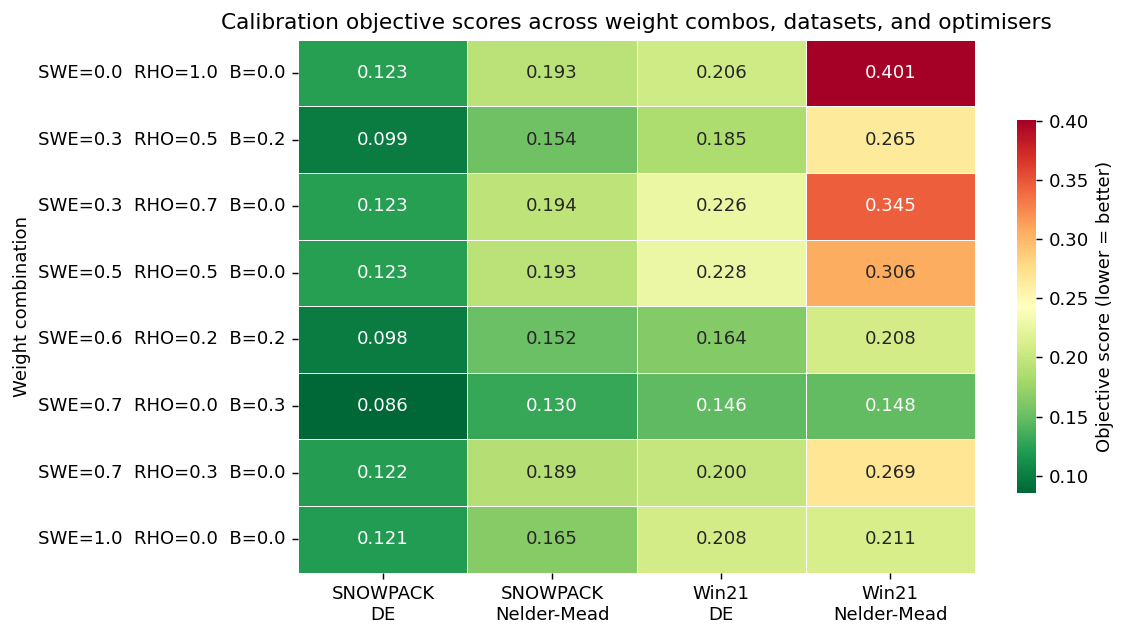

In [15]:
df['run'] = df['dataset'] + '\n' + df['algorithm']
col_order = ['SNOWPACK\nDE', 'SNOWPACK\nNelder-Mead', 'Win21\nDE', 'Win21\nNelder-Mead']
pivot = df.pivot_table(index='wlabel', columns='run', values='best_value', aggfunc='first')
pivot = pivot.reindex(index=weight_order, columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, ax=ax,
    cmap='RdYlGn_r', annot=True, fmt='.3f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Objective score (lower = better)', 'shrink': 0.7}
)
ax.set_xlabel('')
ax.set_ylabel('Weight combination')
ax.set_title('Calibration objective scores across weight combos, datasets, and optimisers')
plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/01_score_heatmap.png', bbox_inches='tight')
plt.show()

## 2 — DE vs Nelder-Mead: head-to-head
Each point = one (dataset, weight combo) pair. Points **above** the diagonal → Nelder-Mead wins; **below** → DE wins.

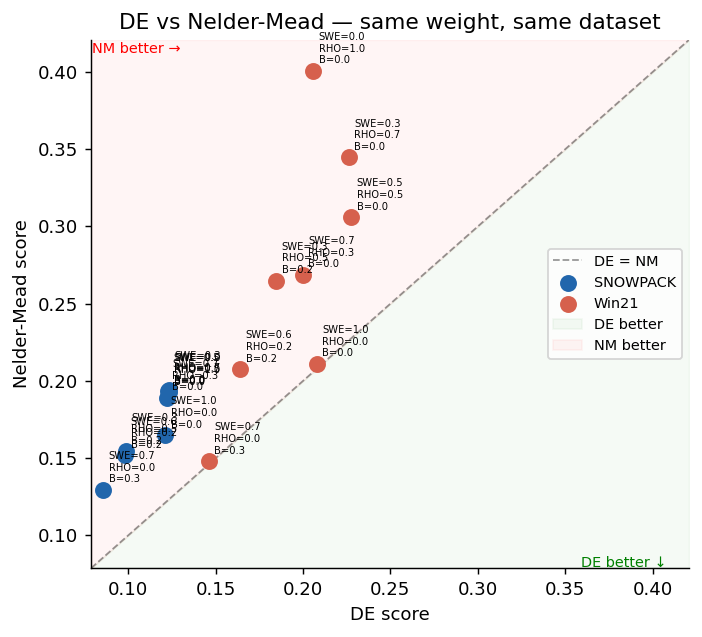

In [16]:
de  = df[df['algorithm'] == 'DE'][['dataset','wlabel','best_value']].rename(columns={'best_value':'score_DE'})
nm  = df[df['algorithm'] == 'Nelder-Mead'][['dataset','wlabel','best_value']].rename(columns={'best_value':'score_NM'})
cmp = de.merge(nm, on=['dataset','wlabel'])

fig, ax = plt.subplots(figsize=(5.5, 5))
lim_min = cmp[['score_DE','score_NM']].min().min() * 0.92
lim_max = cmp[['score_DE','score_NM']].max().max() * 1.05
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1, alpha=0.4, label='DE = NM')

for dataset, grp in cmp.groupby('dataset'):
    ax.scatter(grp['score_DE'], grp['score_NM'],
               color=DATASET_COLORS[dataset], s=70, zorder=3, label=dataset)
    for _, row in grp.iterrows():
        label = row['wlabel'].replace('  ', '\n')
        ax.annotate(label, (row['score_DE'], row['score_NM']),
                    fontsize=5.5, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

ax.fill_between([lim_min, lim_max], [lim_min, lim_min], [lim_min, lim_max],
                alpha=0.04, color='green', label='DE better')
ax.fill_between([lim_min, lim_max], [lim_min, lim_max], [lim_max, lim_max],
                alpha=0.04, color='red', label='NM better')
ax.text(lim_max*0.97, lim_min*1.01, 'DE better ↓', ha='right', fontsize=8, color='green')
ax.text(lim_min*1.01, lim_max*0.98, 'NM better →', ha='left',  fontsize=8, color='red')

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('DE score')
ax.set_ylabel('Nelder-Mead score')
ax.set_title('DE vs Nelder-Mead — same weight, same dataset')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/02_DE_vs_NM.png', bbox_inches='tight')
plt.show()

## 3 — Weight Sweep: SWE ↔ Density trade-off (w_BIAS = 0)
Moving from pure SWE (w_SWE=1) to pure density (w_SWE=0). Shows how the *achievable* score changes and where the sweet spot is.

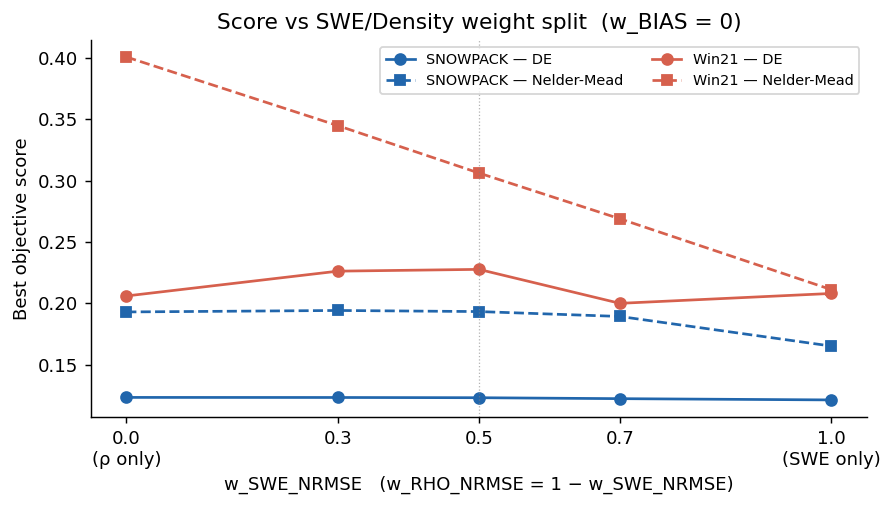

In [17]:
sweep = df[df['w_SWE_NBIAS'] == 0].copy()

fig, ax = plt.subplots(figsize=(7, 4))
for dataset in ['SNOWPACK', 'Win21']:
    for alg in ['DE', 'Nelder-Mead']:
        sub = sweep[(sweep['dataset'] == dataset) & (sweep['algorithm'] == alg)]
        sub = sub.sort_values('w_SWE_NRMSE')
        if sub.empty:
            continue
        ax.plot(sub['w_SWE_NRMSE'], sub['best_value'],
                color=DATASET_COLORS[dataset],
                linestyle=ALG_LINESTYLE[alg],
                marker=ALG_MARKERS[alg],
                markersize=6, lw=1.5,
                label=f'{dataset} — {alg}')

ax.set_xlabel('w_SWE_NRMSE   (w_RHO_NRMSE = 1 − w_SWE_NRMSE)')
ax.set_ylabel('Best objective score')
ax.set_title('Score vs SWE/Density weight split  (w_BIAS = 0)')
ax.set_xticks([0, 0.3, 0.5, 0.7, 1.0])
ax.set_xticklabels(['0.0\n(ρ only)', '0.3', '0.5', '0.7', '1.0\n(SWE only)'])
ax.axvline(0.5, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/03_weight_sweep.png', bbox_inches='tight')
plt.show()

## 4 — Bias Penalty Effect
Compares runs at similar w_SWE with and without a bias term. Does penalising systematic error actually help?

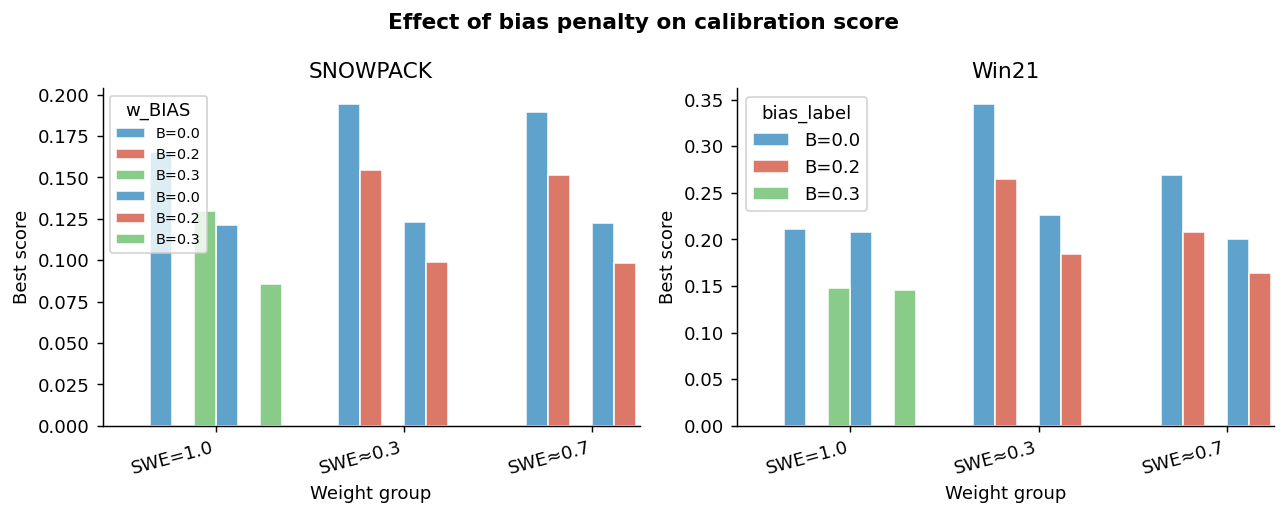

In [18]:
# Group comparable runs: same w_SWE reference point, vary w_BIAS
bias_groups = {
    'SWE=1.0': [
        (1.0, 0.0, 0.0),   # baseline
        (0.7, 0.0, 0.3),   # swap density weight for bias
    ],
    'SWE≈0.7': [
        (0.7, 0.3, 0.0),   # no bias
        (0.6, 0.2, 0.2),   # with bias
    ],
    'SWE≈0.3': [
        (0.3, 0.7, 0.0),   # no bias
        (0.3, 0.5, 0.2),   # with bias
    ],
}

rows = []
for group_name, combos in bias_groups.items():
    for (ws, wr, wb) in combos:
        mask = ((df['w_SWE_NRMSE'] == ws) &
                (df['w_RHO_NRMSE'] == wr) &
                (df['w_SWE_NBIAS'] == wb))
        sub = df[mask].copy()
        sub['group'] = group_name
        sub['bias_label'] = f'B={wb:.1f}'
        rows.append(sub)

bias_df = pd.concat(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, dataset in zip(axes, ['SNOWPACK', 'Win21']):
    sub = bias_df[bias_df['dataset'] == dataset]
    for alg, grp in sub.groupby('algorithm'):
        pivot_b = grp.pivot_table(index='group', columns='bias_label', values='best_value', aggfunc='first')
        pivot_b.plot(kind='bar', ax=ax, alpha=0.85,
                     color=['#4393c3','#d6604d','#74c476'],
                     edgecolor='white', width=0.35,
                     position=0 if alg == 'DE' else 1,
                     legend=(alg == 'DE'))
    ax.set_title(f'{dataset}')
    ax.set_xlabel('Weight group')
    ax.set_ylabel('Best score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    ax.axhline(0, color='k', lw=0.5)

axes[0].legend(title='w_BIAS', fontsize=8)
fig.suptitle('Effect of bias penalty on calibration score', fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/04_bias_effect.png', bbox_inches='tight')
plt.show()

## 5 — Calibrated Parameters: rho_max and rho_null
The two density parameters are the most physically interpretable. How much do they shift as the weight composition changes?

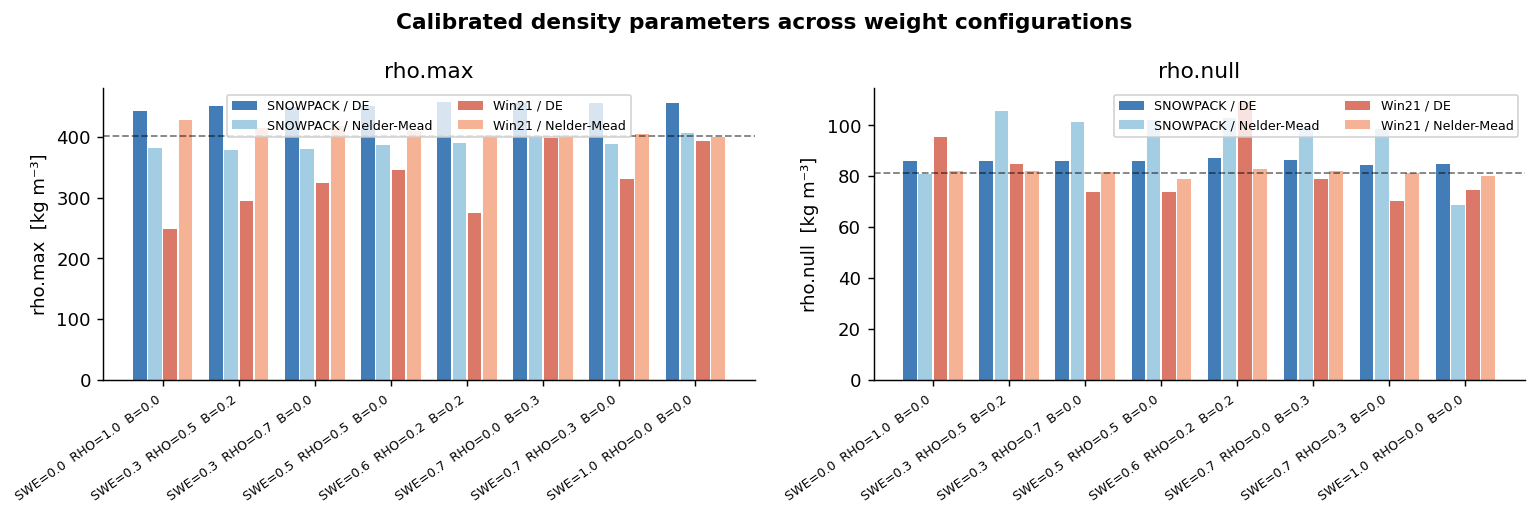

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (par, unit) in zip(axes, [('rho.max_phys', 'kg m⁻³'), ('rho.null_phys', 'kg m⁻³')]):
    plot_df = df[['dataset','algorithm','wlabel', par]].copy()
    plot_df['run'] = plot_df['dataset'] + ' / ' + plot_df['algorithm']
    pivot = plot_df.pivot_table(index='wlabel', columns='run', values=par, aggfunc='first')
    pivot = pivot.reindex(weight_order)

    x = np.arange(len(pivot))
    n_cols = len(pivot.columns)
    width = 0.8 / n_cols
    colors = ['#2166ac','#92c5de','#d6604d','#f4a582']

    for i, col in enumerate(pivot.columns):
        ax.bar(x + i * width - 0.4 + width/2, pivot[col],
               width=width * 0.9, label=col, color=colors[i % len(colors)], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=7)
    ax.set_ylabel(f'{par.replace("_phys","")}  [{unit}]')
    ax.set_title(par.replace('_phys', ''))
    ax.legend(fontsize=7, ncol=2)

    # Reference lines: default pydeltasnow values
    ref = {'rho.max_phys': 401.26, 'rho.null_phys': 81.19}
    ax.axhline(ref[par], color='black', lw=1, ls='--', alpha=0.5, label='default')

fig.suptitle('Calibrated density parameters across weight configurations', fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/05_density_params.png', bbox_inches='tight')
plt.show()

## 7 — Best run per dataset × algorithm
Quick summary table: which weight combination gives the lowest score for each group?

In [20]:
best = (
    df.loc[df.groupby(['dataset','algorithm'])['best_value'].idxmin()]
    [['dataset','algorithm','w_SWE_NRMSE','w_RHO_NRMSE','w_SWE_NBIAS','best_value',
      'rho.max_phys','rho.null_phys','c.ov_phys','k.ov_phys','k_phys','tau_phys','eta.null_phys']]
    .sort_values(['dataset','algorithm'])
    .reset_index(drop=True)
)
best.columns = ['Dataset','Algorithm','w_SWE','w_RHO','w_BIAS','Score',
                'ρ_max','ρ_null','c_ov','k_ov','k','τ','η_null']

# Pretty-print
pd.set_option('display.float_format', lambda x: f'{x:.4g}')
display(best)

,Dataset,Algorithm,w_SWE,w_RHO,w_BIAS,Score,ρ_max,ρ_null,c_ov,k_ov,k,τ,η_null
0,SNOWPACK,DE,0.7,0,0.3,0.08569,455.3,86.46,0.006465,0.3446,0.08757,0.003669,4.117e+07
1,SNOWPACK,Nelder-Mead,0.7,0,0.3,0.1296,399.1,99.57,0.0005373,0.4144,0.02639,0.02308,8.77e+06
2,Win21,DE,0.7,0,0.3,0.1461,398.1,79.1,0.002444,0.5397,0.07444,0.009216,2.148e+07
3,Win21,Nelder-Mead,0.7,0,0.3,0.1482,403.6,82,0.000552,0.4037,0.02991,0.02118,8.612e+06


## 8 — Calibrated Parameters: Cleveland Dot Plot per Parameter
Each dot = one calibration run. **Grey band** = optimisation bounds (feasible space). **Dashed line** = pydeltasnow default. Parameters with log-scale axes are flagged. Key diagnostics: bound-hitting, inter-dataset agreement, parameter stability across weight configurations.

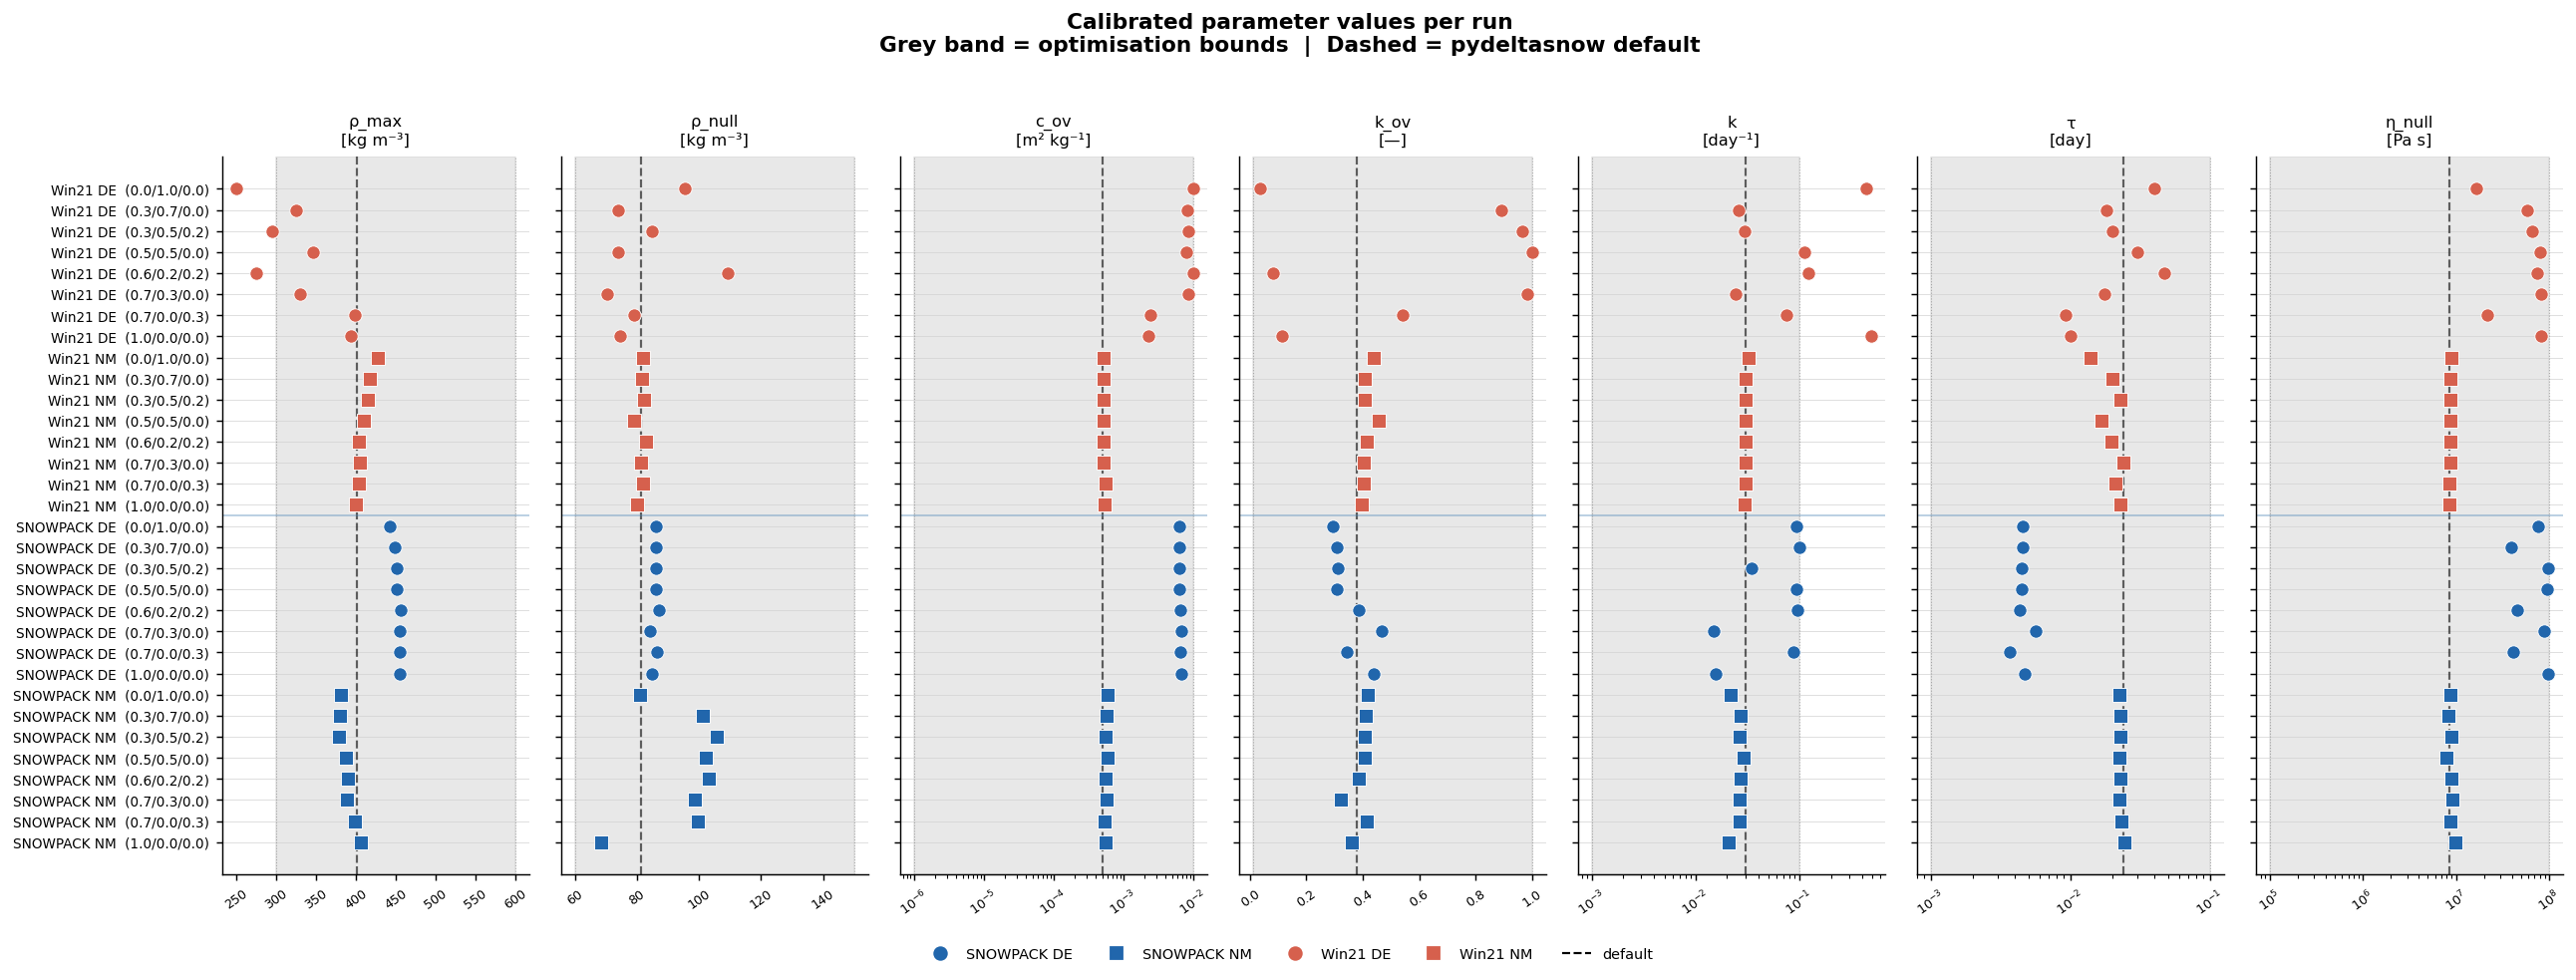

In [21]:

PAR_META = {
    'rho.max':   dict(lo=300,  hi=600,  default=401.26,  label='ρ_max',    unit='kg m⁻³',  log=False),
    'rho.null':  dict(lo=60,   hi=150,  default=81.19,   label='ρ_null',   unit='kg m⁻³',  log=False),
    'c.ov':      dict(lo=1e-6, hi=0.01, default=5.1e-4,  label='c_ov',     unit='m² kg⁻¹', log=True),
    'k.ov':      dict(lo=0.01, hi=1.0,  default=0.379,   label='k_ov',     unit='—',        log=False),
    'k':         dict(lo=0.001,hi=0.1,  default=0.03,    label='k',        unit='day⁻¹',   log=True),
    'tau':       dict(lo=0.001,hi=0.1,  default=0.024,   label='τ',        unit='day',      log=True),
    'eta.null':  dict(lo=1e5,  hi=1e8,  default=8.52e6,  label='η_null',   unit='Pa s',     log=True),
}

# ── Build a short, readable y-axis label per run ──────────────────────────────
def short_label(row):
    ws, wr, wb = row['w_SWE_NRMSE'], row['w_RHO_NRMSE'], row['w_SWE_NBIAS']
    alg = 'DE' if row['algorithm'] == 'DE' else 'NM'
    ds  = row['dataset']
    return f"{ds} {alg}  ({ws:.1f}/{wr:.1f}/{wb:.1f})"

df['run_label'] = df.apply(short_label, axis=1)

# Sort rows: SNOWPACK first, then Win21; within each: DE before NM; then by w_SWE
df_sorted = df.sort_values(
    ['dataset', 'algorithm', 'w_SWE_NRMSE', 'w_RHO_NRMSE'],
    ascending=[False, True, True, False]   # SNOWPACK > Win21, DE < NM
).reset_index(drop=True)

y_labels = df_sorted['run_label'].tolist()
y_pos    = np.arange(len(y_labels))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 7, figsize=(20, 7), sharey=True)
fig.suptitle('Calibrated parameter values per run\n'
             'Grey band = optimisation bounds  |  Dashed = pydeltasnow default',
             fontweight='bold', y=1.02)

for ax, par in zip(axes, PAR_NAMES):
    meta = PAR_META[par]
    col  = par + '_phys'

    # Grey feasible band
    ax.axvspan(meta['lo'], meta['hi'], color='lightgrey', alpha=0.5, zorder=0)
    ax.axvline(meta['lo'],     color='grey',  lw=0.6, ls=':', alpha=0.6)
    ax.axvline(meta['hi'],     color='grey',  lw=0.6, ls=':', alpha=0.6)
    ax.axvline(meta['default'],color='black', lw=1.2, ls='--', alpha=0.6, zorder=1)

    # Horizontal guide lines for readability
    for yi in y_pos:
        ax.axhline(yi, color='lightgrey', lw=0.4, zorder=0)

    # Dots
    for yi, (_, row) in zip(y_pos, df_sorted.iterrows()):
        val = row[col]
        if not np.isfinite(val):
            continue
        color  = DATASET_COLORS[row['dataset']]
        marker = ALG_MARKERS[row['algorithm']]
        ax.scatter(val, yi, color=color, marker=marker,
                   s=55, zorder=3, linewidths=0.5, edgecolors='white')

    if meta['log']:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10, labelOnlyBase=True))

    ax.set_title(f"{meta['label']}\n[{meta['unit']}]", fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=35)
    ax.spines[['top', 'right']].set_visible(False)

# Y-axis labels only on the leftmost subplot (sharey=True propagates ticks)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(y_labels, fontsize=7.5)
axes[0].invert_yaxis()   # top = first run

# Divider line between SNOWPACK and Win21 blocks
n_snowpack = (df_sorted['dataset'] == 'SNOWPACK').sum()
for ax in axes:
    ax.axhline(n_snowpack - 0.5, color='steelblue', lw=1, ls='-', alpha=0.4)

# Legend
legend_elements = [
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='o', ls='None', markersize=7, label='SNOWPACK DE'),
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='s', ls='None', markersize=7, label='SNOWPACK NM'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='o', ls='None', markersize=7, label='Win21 DE'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='s', ls='None', markersize=7, label='Win21 NM'),
    Line2D([0],[0], color='black', lw=1.2, ls='--', label='default'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/08_parameter_cleveland.png',
            bbox_inches='tight')
plt.show()


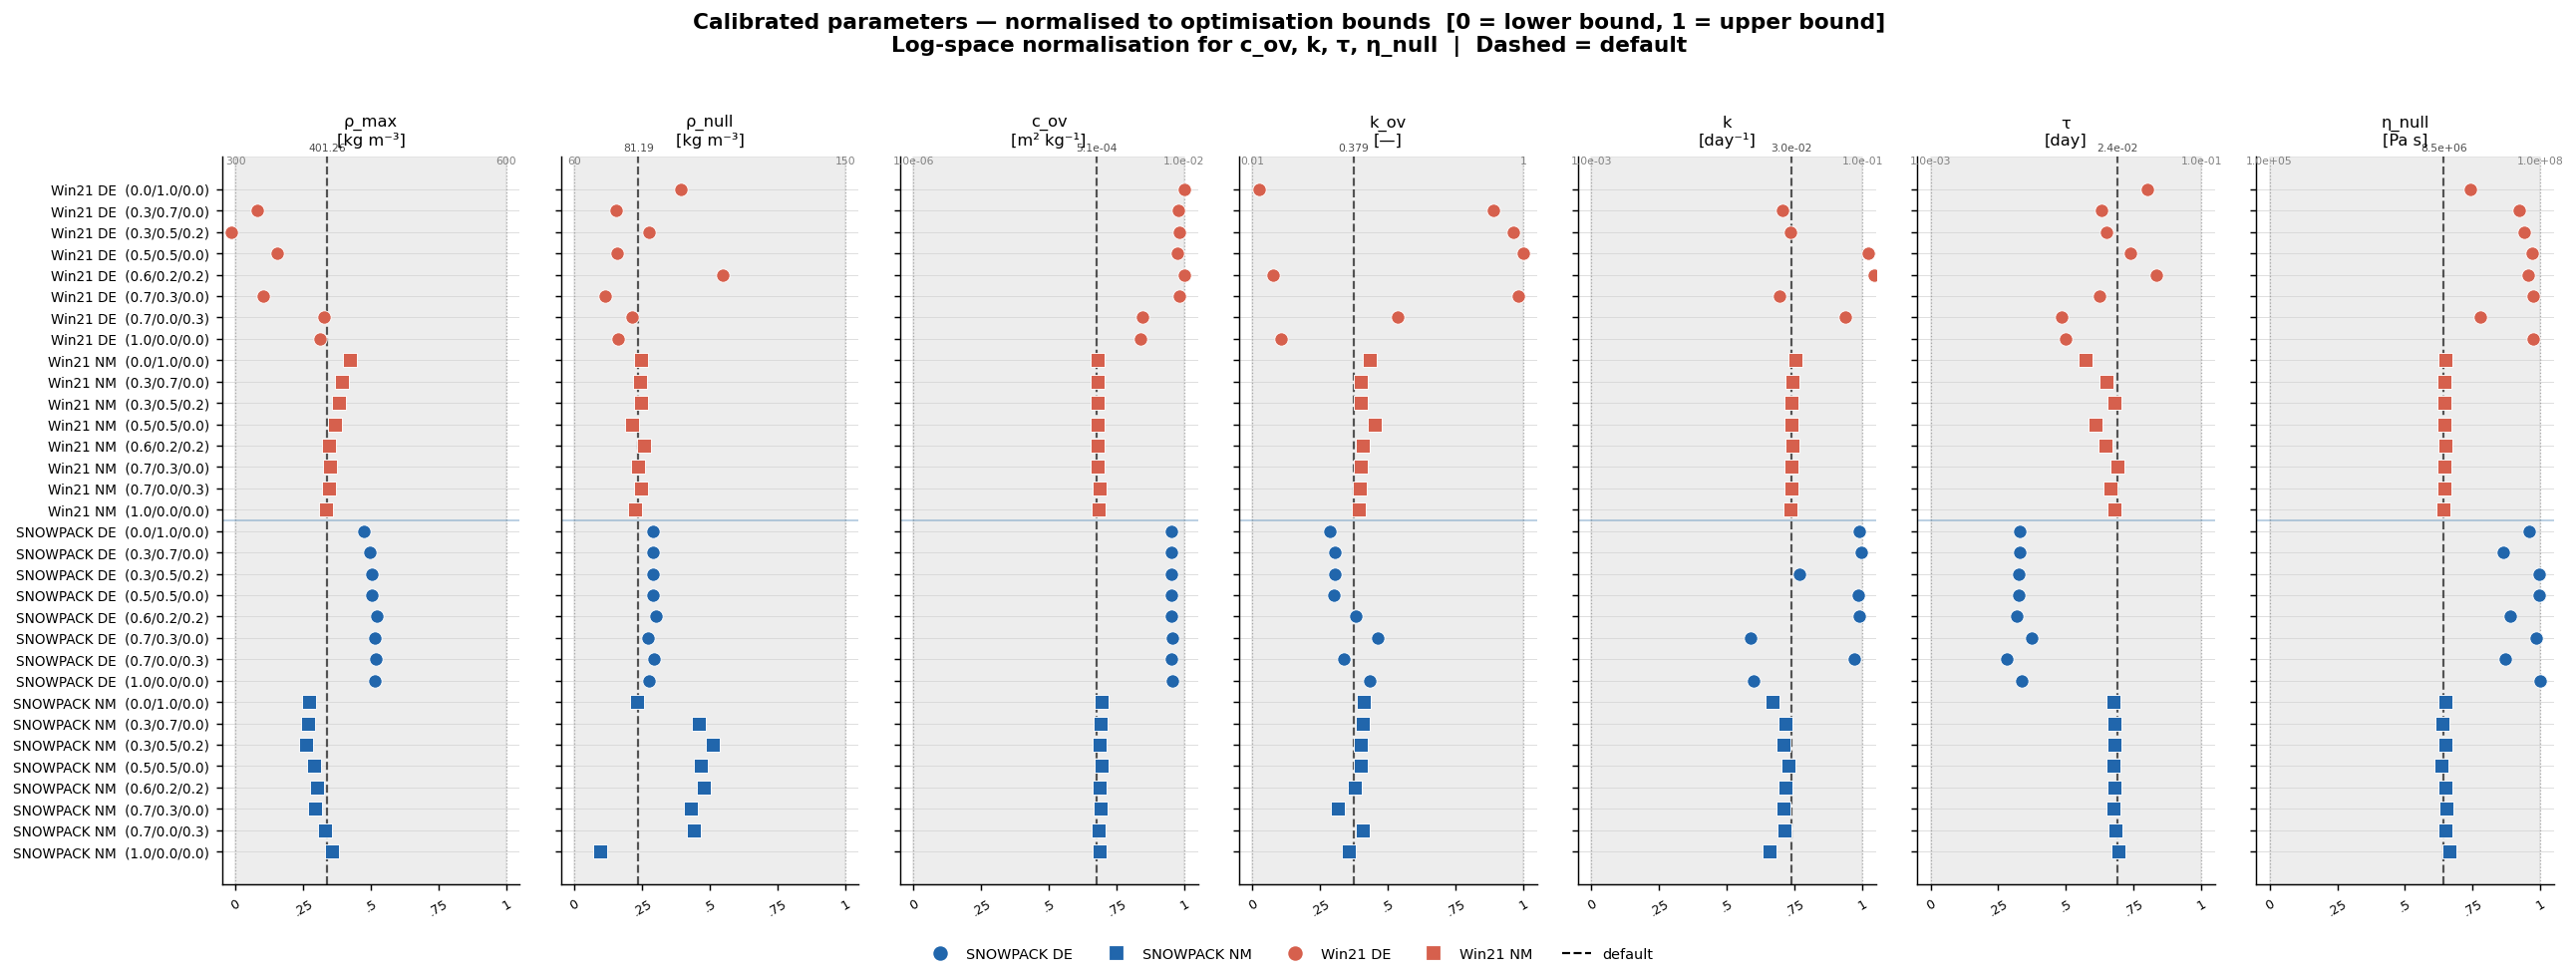

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

PAR_META = {
    'rho.max':  dict(lo=300,   hi=600,  default=401.26, label='ρ_max',  unit='kg m⁻³',  log=False),
    'rho.null': dict(lo=60,    hi=150,  default=81.19,  label='ρ_null', unit='kg m⁻³',  log=False),
    'c.ov':     dict(lo=1e-6,  hi=0.01, default=5.1e-4, label='c_ov',   unit='m² kg⁻¹', log=True),
    'k.ov':     dict(lo=0.01,  hi=1.0,  default=0.379,  label='k_ov',   unit='—',        log=False),
    'k':        dict(lo=0.001, hi=0.1,  default=0.03,   label='k',      unit='day⁻¹',   log=True),
    'tau':      dict(lo=0.001, hi=0.1,  default=0.024,  label='τ',      unit='day',      log=True),
    'eta.null': dict(lo=1e5,   hi=1e8,  default=8.52e6, label='η_null', unit='Pa s',     log=True),
}

def norm_val(v, lo, hi, log):
    """Normalise v to [0, 1] within [lo, hi]; log-space for log params."""
    if log:
        return (np.log10(v) - np.log10(lo)) / (np.log10(hi) - np.log10(lo))
    return (v - lo) / (hi - lo)

# ── Build run labels and sort ─────────────────────────────────────────────────
def short_label(row):
    ws, wr, wb = row['w_SWE_NRMSE'], row['w_RHO_NRMSE'], row['w_SWE_NBIAS']
    alg = 'DE' if row['algorithm'] == 'DE' else 'NM'
    return f"{row['dataset']} {alg}  ({ws:.1f}/{wr:.1f}/{wb:.1f})"

df['run_label'] = df.apply(short_label, axis=1)

df_sorted = df.sort_values(
    ['dataset', 'algorithm', 'w_SWE_NRMSE', 'w_RHO_NRMSE'],
    ascending=[False, True, True, False]
).reset_index(drop=True)

y_labels = df_sorted['run_label'].tolist()
y_pos    = np.arange(len(y_labels))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 7, figsize=(20, 7), sharey=True, sharex=True)
fig.suptitle(
    'Calibrated parameters — normalised to optimisation bounds  [0 = lower bound, 1 = upper bound]\n'
    'Log-space normalisation for c_ov, k, τ, η_null  |  Dashed = default',
    fontweight='bold', y=1.02
)

for ax, par in zip(axes, PAR_NAMES):
    meta = PAR_META[par]
    col  = par + '_phys'
    default_norm = norm_val(meta['default'], meta['lo'], meta['hi'], meta['log'])

    # Full feasible band [0, 1]
    ax.axvspan(0, 1, color='lightgrey', alpha=0.4, zorder=0)
    ax.axvline(0,            color='grey',  lw=0.7, ls=':', alpha=0.6)
    ax.axvline(1,            color='grey',  lw=0.7, ls=':', alpha=0.6)
    ax.axvline(default_norm, color='black', lw=1.2, ls='--', alpha=0.65, zorder=1)

    # Horizontal guide lines
    for yi in y_pos:
        ax.axhline(yi, color='lightgrey', lw=0.4, zorder=0)

    # Dots
    for yi, (_, row) in zip(y_pos, df_sorted.iterrows()):
        val = row[col]
        if not np.isfinite(val) or val <= 0:
            continue
        val_norm = norm_val(val, meta['lo'], meta['hi'], meta['log'])
        color  = DATASET_COLORS[row['dataset']]
        marker = ALG_MARKERS[row['algorithm']]
        ax.scatter(val_norm, yi, color=color, marker=marker,
                   s=55, zorder=3, linewidths=0.5, edgecolors='white')

    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0', '.25', '.5', '.75', '1'], fontsize=7)
    ax.set_title(f"{meta['label']}\n[{meta['unit']}]", fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate lo / hi / default in physical units at top
    fmt = lambda v: f'{v:.1e}' if meta['log'] else f'{v:g}'
    ax.text(0,            -1.2, fmt(meta['lo']),      ha='center', fontsize=6, color='grey')
    ax.text(1,            -1.2, fmt(meta['hi']),      ha='center', fontsize=6, color='grey')
    ax.text(default_norm, -1.8, fmt(meta['default']), ha='center', fontsize=6, color='black', alpha=0.7)

# Y labels on leftmost panel
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(y_labels, fontsize=7.5)
axes[0].invert_yaxis()

# Divider between SNOWPACK and Win21
n_snowpack = (df_sorted['dataset'] == 'SNOWPACK').sum()
for ax in axes:
    ax.axhline(n_snowpack - 0.5, color='steelblue', lw=1, ls='-', alpha=0.4)

# Legend
legend_elements = [
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='o', ls='None', markersize=7, label='SNOWPACK DE'),
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='s', ls='None', markersize=7, label='SNOWPACK NM'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='o', ls='None', markersize=7, label='Win21 DE'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='s', ls='None', markersize=7, label='Win21 NM'),
    Line2D([0],[0], color='black', lw=1.2, ls='--', label='default'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/09_parameter_normalized.png',
            bbox_inches='tight')
plt.show()

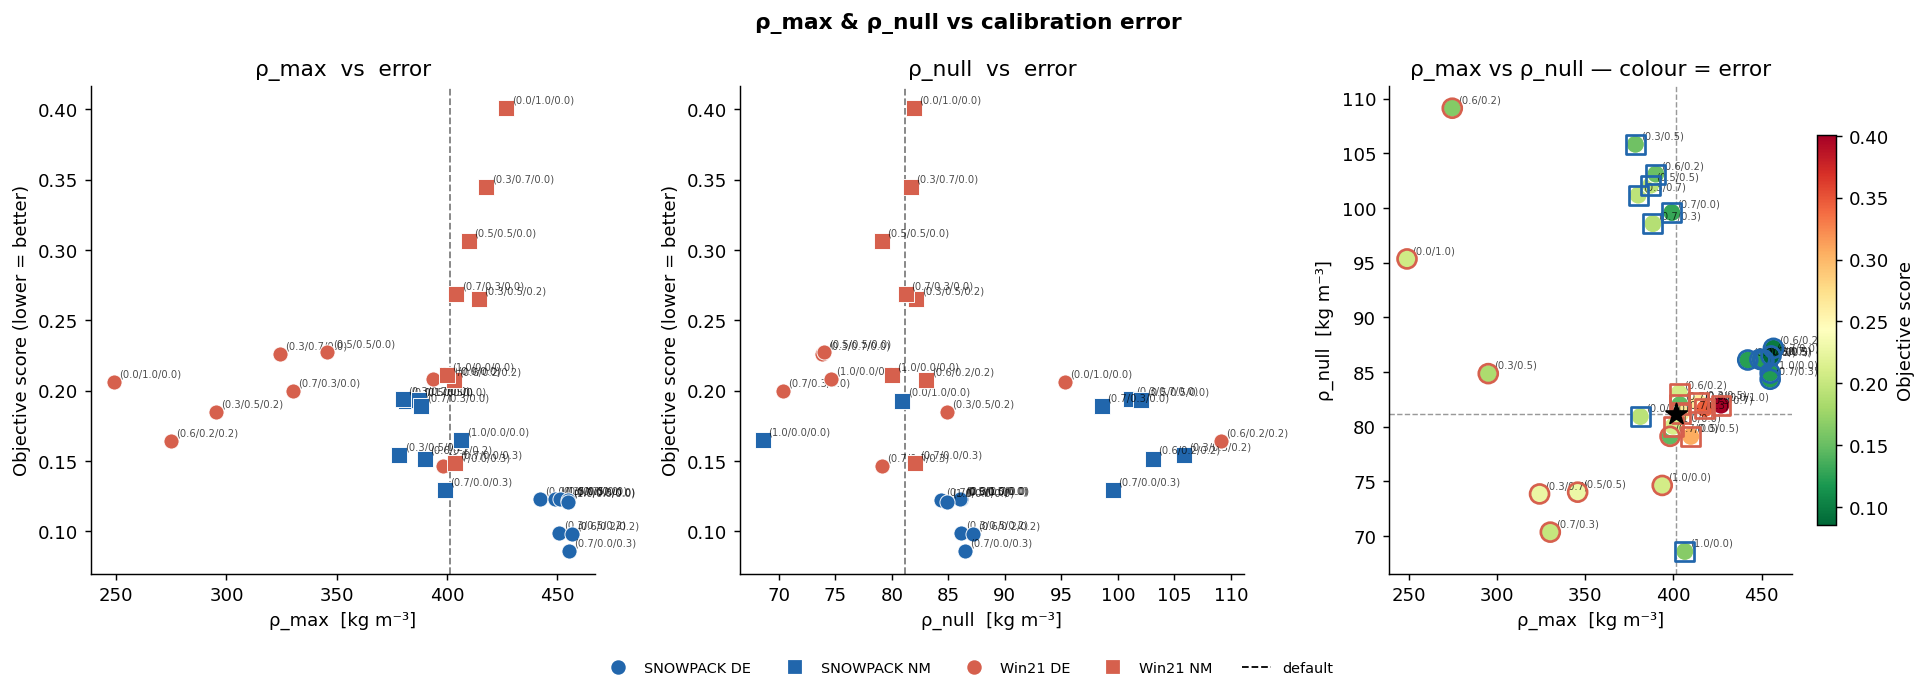

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ρ_max & ρ_null vs calibration error', fontweight='bold')

# ── shared style helpers ──────────────────────────────────────────────────────
def scatter_run(ax, x, y, row, s=70, **kw):
    ax.scatter(x, y,
               color=DATASET_COLORS[row['dataset']],
               marker=ALG_MARKERS[row['algorithm']],
               s=s, edgecolors='white', linewidths=0.5, zorder=3, **kw)

# ── Panel 1: ρ_max vs best_value ─────────────────────────────────────────────
ax = axes[0]
for _, row in df.iterrows():
    scatter_run(ax, row['rho.max_phys'], row['best_value'], row)
    ax.annotate(f"({row['w_SWE_NRMSE']:.1f}/{row['w_RHO_NRMSE']:.1f}/{row['w_SWE_NBIAS']:.1f})",
                (row['rho.max_phys'], row['best_value']),
                fontsize=5.5, xytext=(3, 3), textcoords='offset points', alpha=0.7)

ax.axvline(401.26, color='black', lw=1, ls='--', alpha=0.5, label='default')
ax.set_xlabel('ρ_max  [kg m⁻³]')
ax.set_ylabel('Objective score (lower = better)')
ax.set_title('ρ_max  vs  error')
ax.spines[['top','right']].set_visible(False)

# ── Panel 2: ρ_null vs best_value ────────────────────────────────────────────
ax = axes[1]
for _, row in df.iterrows():
    scatter_run(ax, row['rho.null_phys'], row['best_value'], row)
    ax.annotate(f"({row['w_SWE_NRMSE']:.1f}/{row['w_RHO_NRMSE']:.1f}/{row['w_SWE_NBIAS']:.1f})",
                (row['rho.null_phys'], row['best_value']),
                fontsize=5.5, xytext=(3, 3), textcoords='offset points', alpha=0.7)

ax.axvline(81.19, color='black', lw=1, ls='--', alpha=0.5, label='default')
ax.set_xlabel('ρ_null  [kg m⁻³]')
ax.set_ylabel('Objective score (lower = better)')
ax.set_title('ρ_null  vs  error')
ax.spines[['top','right']].set_visible(False)

# ── Panel 3: ρ_max vs ρ_null, coloured by best_value ────────────────────────
ax = axes[2]
sc = ax.scatter(
    df['rho.max_phys'], df['rho.null_phys'],
    c=df['best_value'],
    cmap='RdYlGn_r',
    s=100, edgecolors='white', linewidths=0.6, zorder=3
)
# Overlay dataset/algorithm markers as outlines
for _, row in df.iterrows():
    ax.scatter(row['rho.max_phys'], row['rho.null_phys'],
               marker=ALG_MARKERS[row['algorithm']],
               facecolors='none',
               edgecolors=DATASET_COLORS[row['dataset']],
               linewidths=1.5, s=110, zorder=4)
    ax.annotate(f"({row['w_SWE_NRMSE']:.1f}/{row['w_RHO_NRMSE']:.1f})",
                (row['rho.max_phys'], row['rho.null_phys']),
                fontsize=5.5, xytext=(3, 3), textcoords='offset points', alpha=0.7)

# Default crosshair
ax.axvline(401.26, color='black', lw=0.8, ls='--', alpha=0.4)
ax.axhline(81.19,  color='black', lw=0.8, ls='--', alpha=0.4)
ax.scatter(401.26, 81.19, marker='*', s=150, color='black', zorder=5, label='default')

plt.colorbar(sc, ax=ax, label='Objective score', shrink=0.8)
ax.set_xlabel('ρ_max  [kg m⁻³]')
ax.set_ylabel('ρ_null  [kg m⁻³]')
ax.set_title('ρ_max vs ρ_null — colour = error')
ax.spines[['top','right']].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='o', ls='None', markersize=7, label='SNOWPACK DE'),
    Line2D([0],[0], color=DATASET_COLORS['SNOWPACK'], marker='s', ls='None', markersize=7, label='SNOWPACK NM'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='o', ls='None', markersize=7, label='Win21 DE'),
    Line2D([0],[0], color=DATASET_COLORS['Win21'],    marker='s', ls='None', markersize=7, label='Win21 NM'),
    Line2D([0],[0], color='black', lw=1, ls='--', label='default'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, -0.06), frameon=False)

plt.tight_layout()
plt.savefig('/Users/jakobwerkgarner/code/mt_dsnow/calibration/plots/10_rho_vs_error.png',
            bbox_inches='tight')
plt.show()

In [24]:
# Define the column groups you want
physical_cols = [ 'rho.max_phys', 'rho.null_phys', 'c.ov_phys', 'k.ov_phys', 'k_phys', 'tau_phys', 'eta.null_phys']

w_cols = [col for col in df.columns if col.startswith('w_')]

# Combine everything
keep_cols = ['dataset', 'algorithm'] + physical_cols + w_cols + ['best_value']

# Create the filtered DataFrame
df_filtered = df[keep_cols].sort_index()


In [25]:
df_filtered

,dataset,algorithm,rho.max_phys,rho.null_phys,c.ov_phys,k.ov_phys,k_phys,tau_phys,eta.null_phys,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,best_value
0,Win21,DE,249,95.33,0.009967,0.0343,0.433,0.04,1.674e+07,0,1,0,0.2059
1,Win21,Nelder-Mead,426.9,81.95,0.0005252,0.4378,0.0322,0.0139,8.86e+06,0,1,0,0.4008
2,SNOWPACK,DE,442.1,86.09,0.006403,0.2936,0.09416,0.004567,7.607e+07,0,1,0,0.1232
3,SNOWPACK,Nelder-Mead,381.2,80.92,0.0005927,0.4181,0.02173,0.02231,8.834e+06,0,1,0,0.1929
4,Win21,DE,295.1,84.84,0.008418,0.9649,0.02946,0.01996,6.664e+07,0.3,0.5,0.2,0.1847
5,Win21,Nelder-Mead,414.4,82.16,0.0005155,0.406,0.03012,0.02272,8.736e+06,0.3,0.5,0.2,0.265
6,SNOWPACK,DE,450.6,86.13,0.006429,0.3124,0.03449,0.004456,9.69e+07,0.3,0.5,0.2,0.09882
7,SNOWPACK,Nelder-Mead,378.4,105.8,0.0005522,0.4076,0.02623,0.02282,8.849e+06,0.3,0.5,0.2,0.1545
8,Win21,DE,324.1,73.83,0.008182,0.8906,0.02566,0.01824,5.862e+07,0.3,0.7,0,0.2262
9,Win21,Nelder-Mead,417.8,81.65,0.0005152,0.4061,0.03054,0.01998,8.648e+06,0.3,0.7,0,0.3448


In [26]:
def return_params(row):
    return (
        "snow_to_swe = SnowToSwe(\n"
        f"    rho_max={row['rho.max_phys']:.15g},\n"
        f"    rho_null={row['rho.null_phys']:.15g},\n"
        f"    c_ov={row['c.ov_phys']:.15g},\n"
        f"    k_ov={row['k.ov_phys']:.15g},\n"
        f"    k={row['k_phys']:.15g},\n"
        f"    tau={row['tau_phys']:.15g},\n"
        f"    eta_null={row['eta.null_phys']:.15g}\n"
        ")"
    )


idx = 1
print(return_params(df_filtered.iloc[idx]))

snow_to_swe = SnowToSwe(
    rho_max=426.917,
    rho_null=81.9547,
    c_ov=0.000525225,
    k_ov=0.437829,
    k=0.0322043,
    tau=0.0139022,
    eta_null=8859780
)


Prepared 240 station×winter tasks for validation.
Generating side-by-side HNW/SWE plots for 32 calibration runs...


Calibration runs:   0%|          | 0/32 [00:00<?, ?it/s]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakob

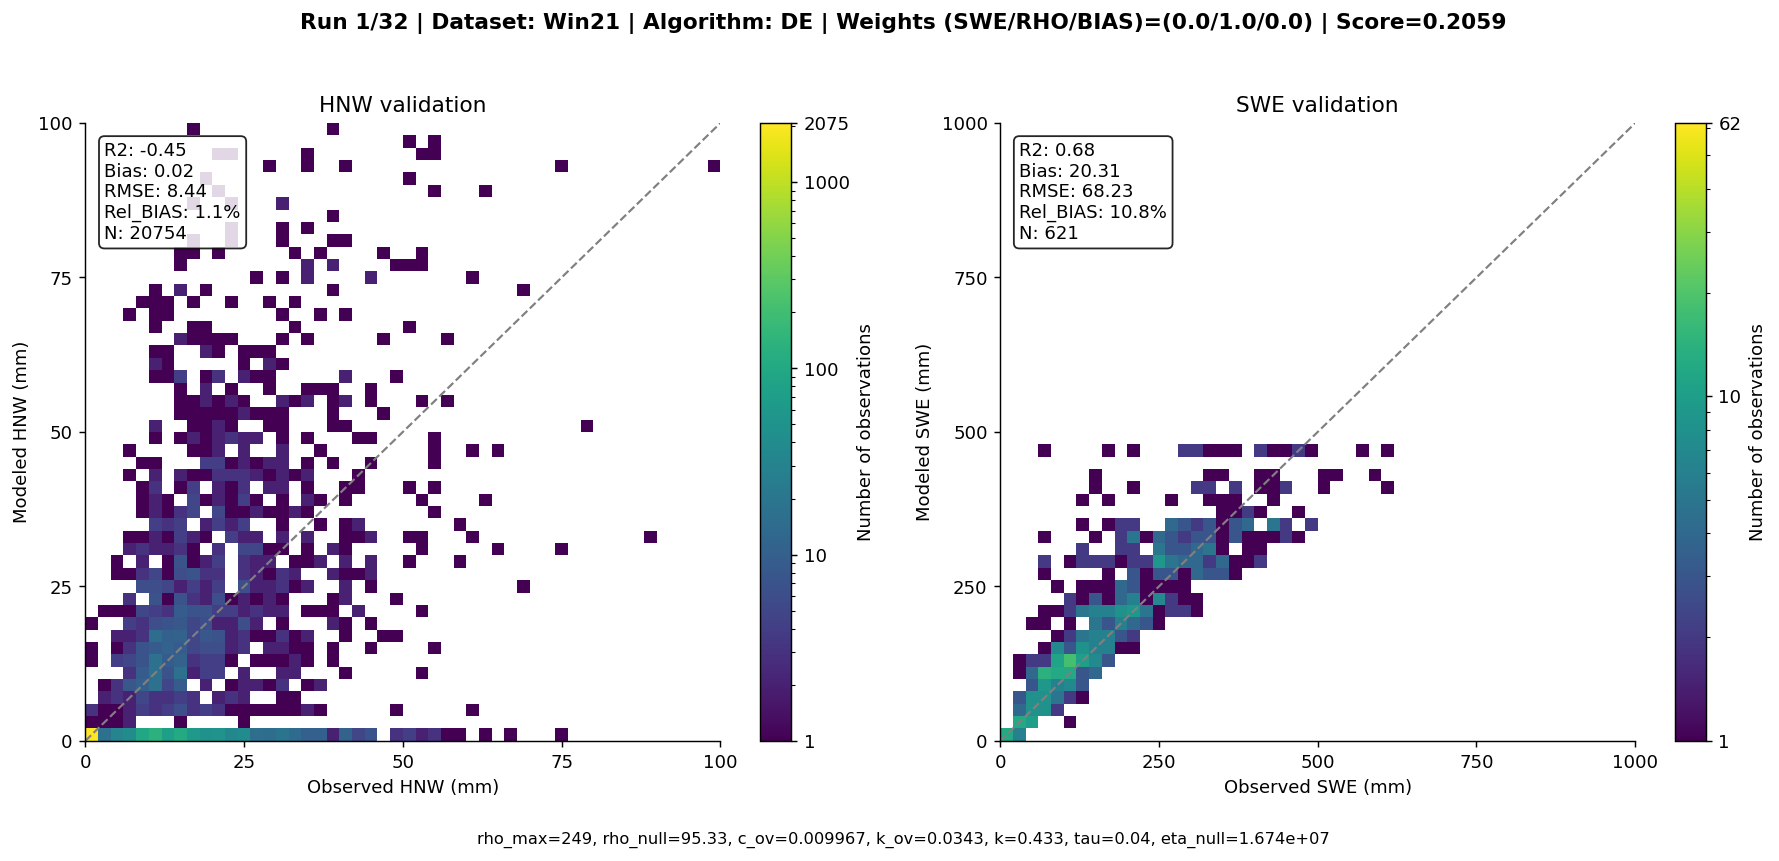

Calibration runs:   3%|▎         | 1/32 [00:14<07:42, 14.91s/it]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


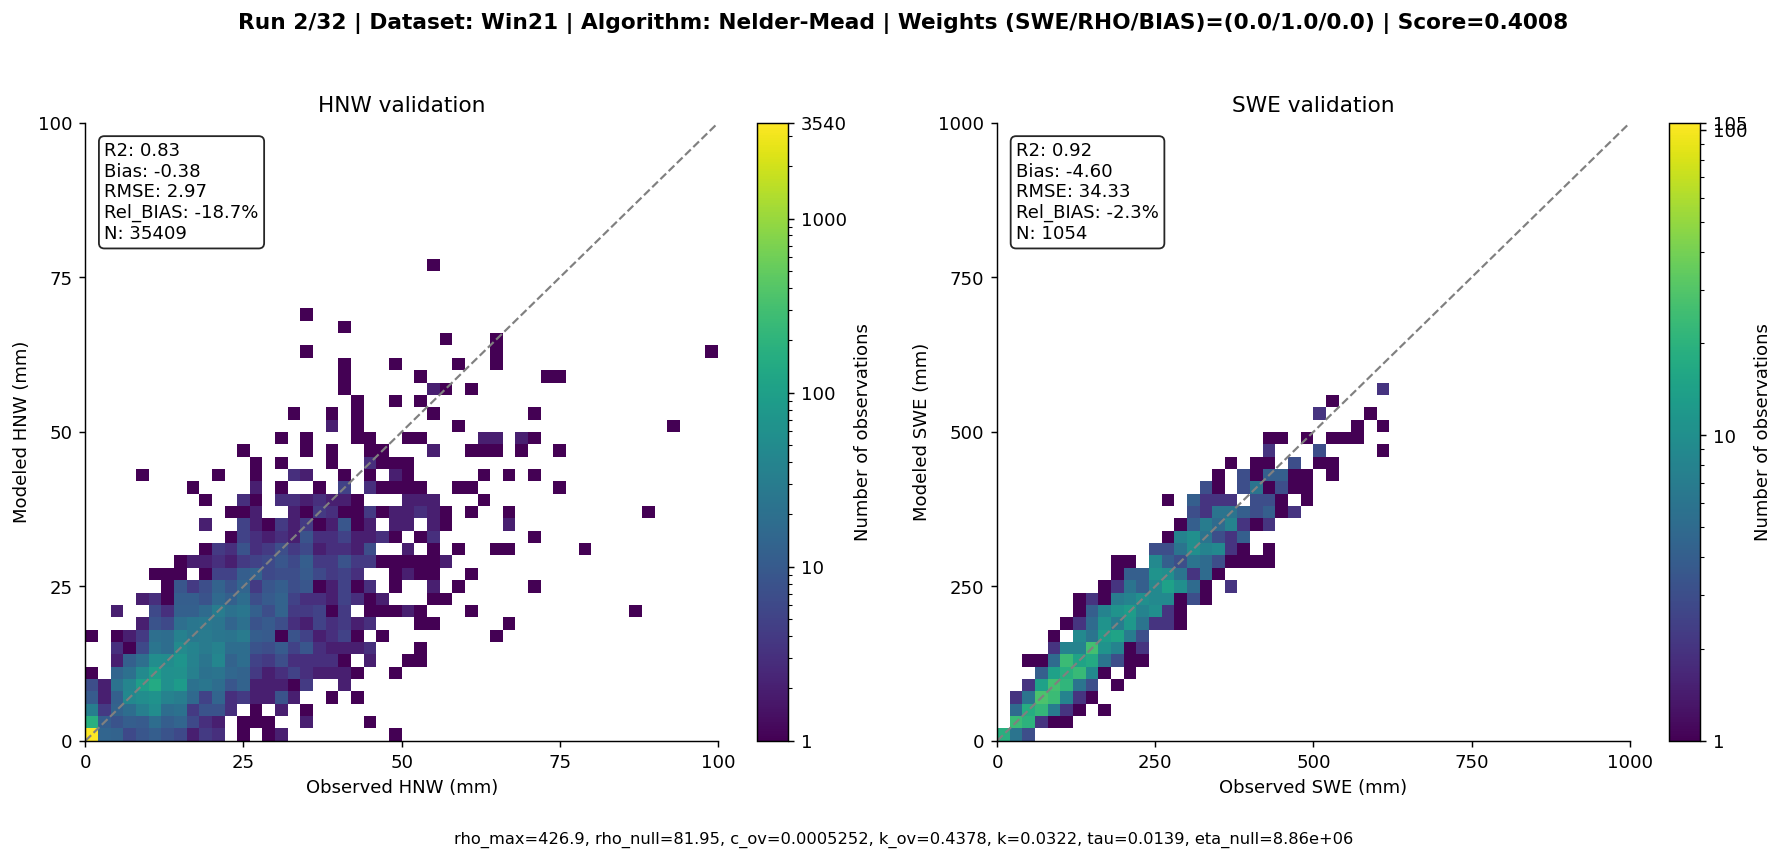

Calibration runs:   6%|▋         | 2/32 [00:55<15:00, 30.03s/it]/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / se

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakob

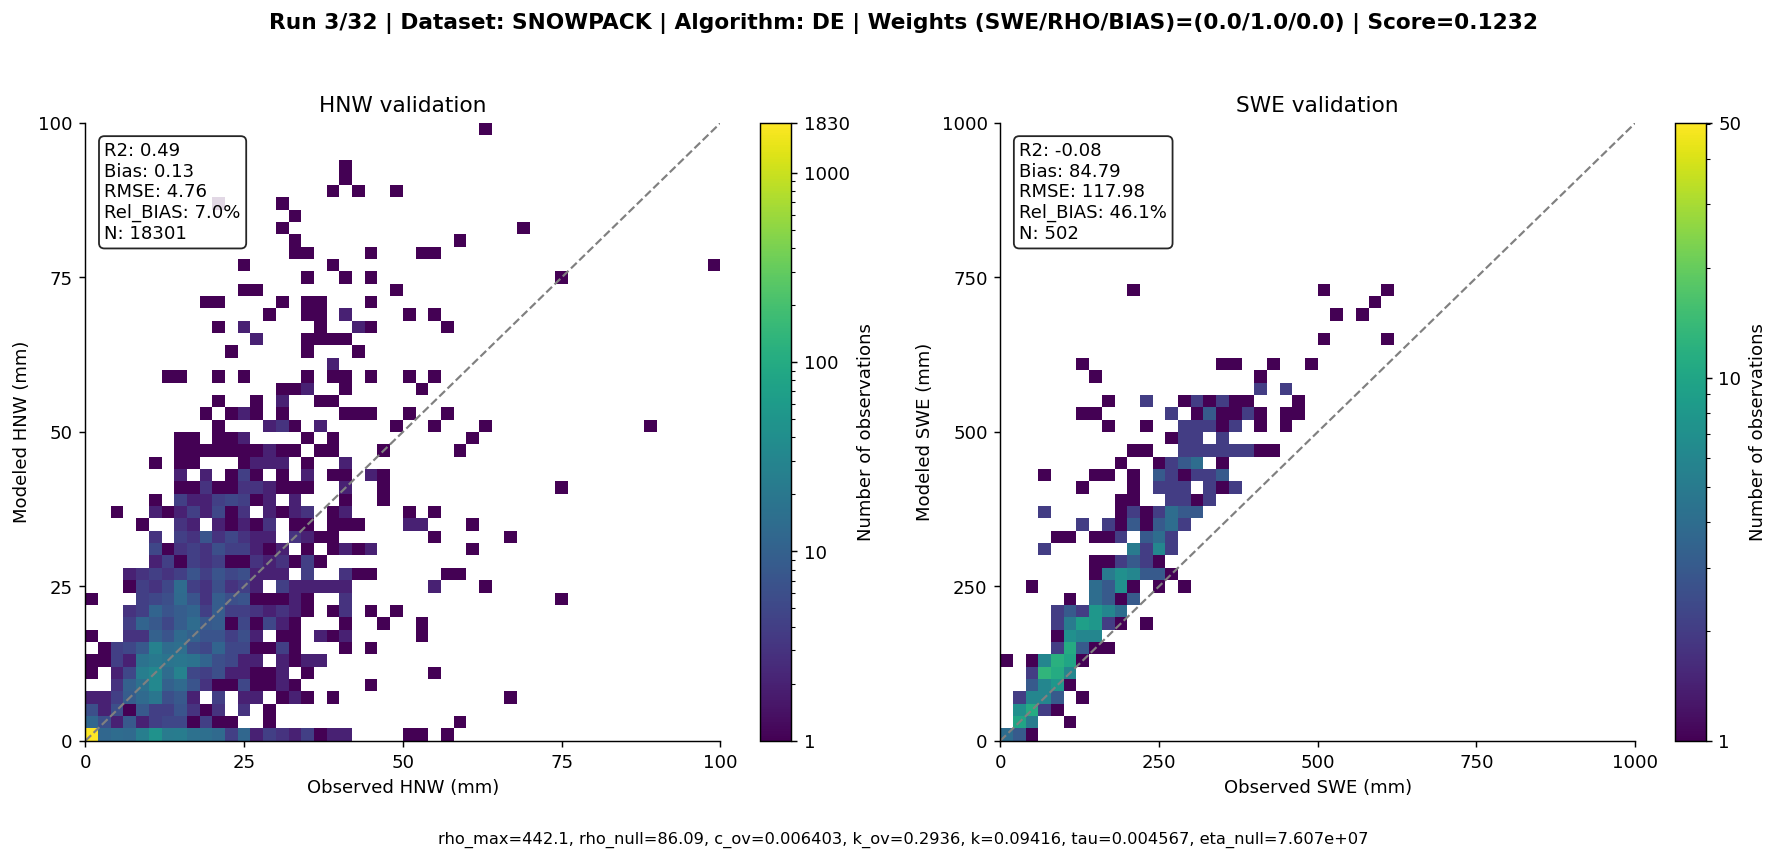

Calibration runs:   9%|▉         | 3/32 [01:15<12:17, 25.42s/it]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


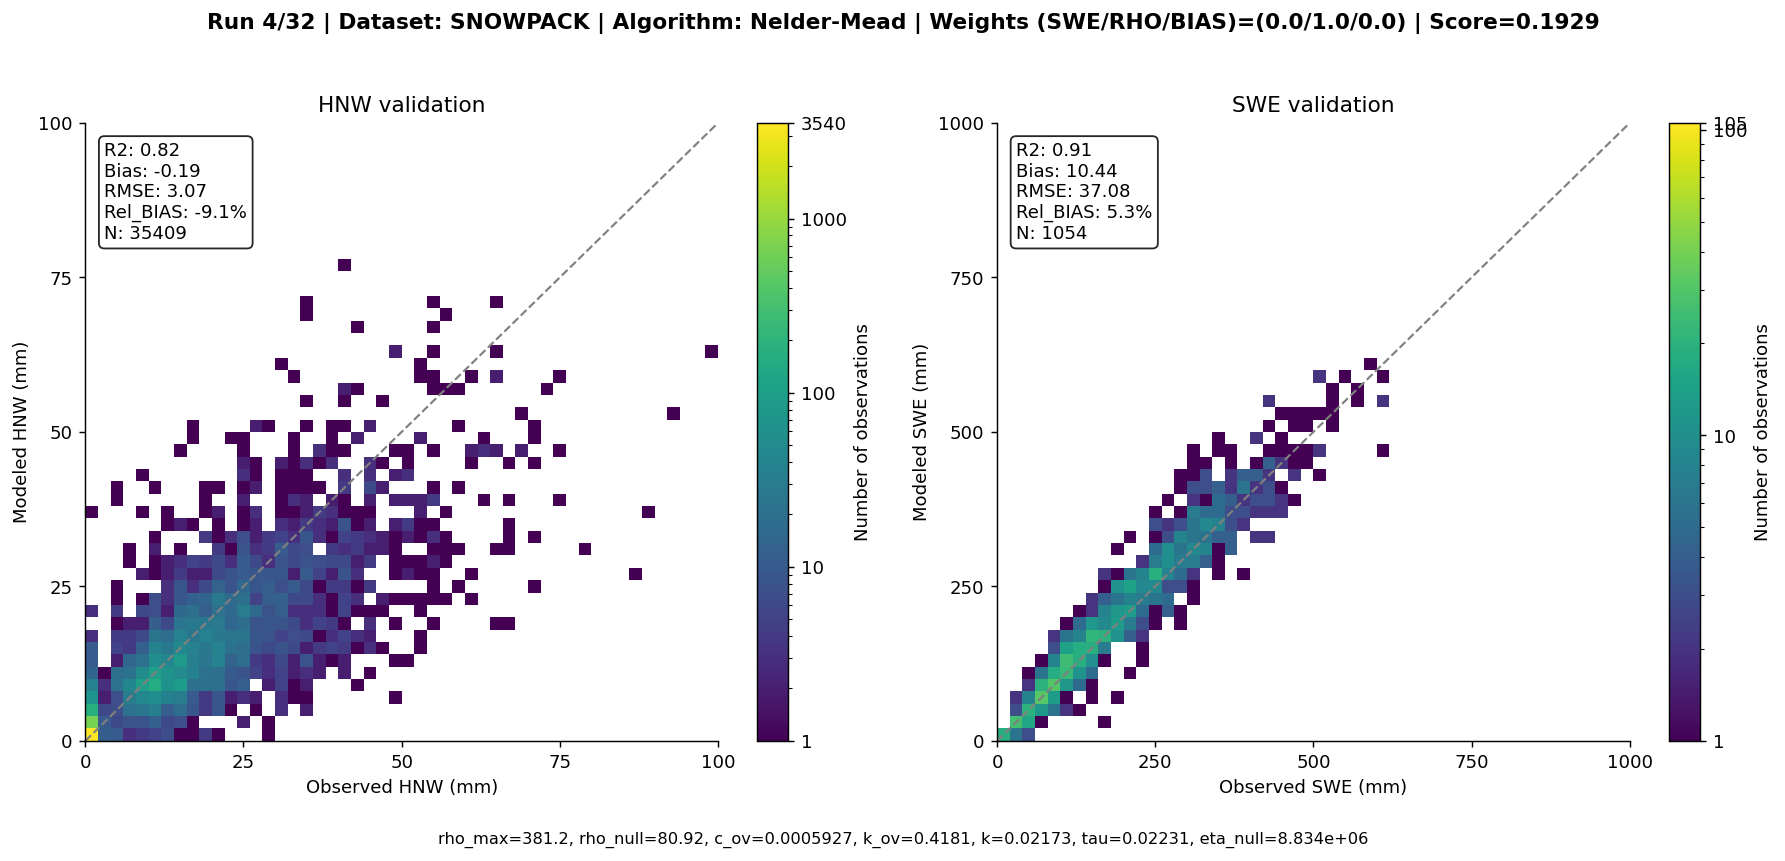

Calibration runs:  12%|█▎        | 4/32 [02:00<15:23, 32.97s/it]/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:292: RuntimeWarning: overflow encountered in exp
  x = ts * EARTH_GRAVITATIONAL_ACCELERATION * swe_hat_d[i] * exp(-self.k * rho_d)  # yesterday
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:299: RuntimeWarning: overflow encountered in exp
  h_dd_cor = np.array(h_d) / (1 + (np.array(swe_hat_d) * EARTH_GRAVITATIONAL_ACCELERATION * ts) / np.array(eta_cor) * exp

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:292: RuntimeWarning: overflow encountered in exp
  x = ts * EARTH_GRAVITATIONAL_ACCELERATION * swe_hat_d[i] * exp(-self.k * rho_d)  # yesterday
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:299: RuntimeWarning: overflow encountered in exp
  h_dd_cor = np.array(h_d) / (1 + (np.array(swe_hat_d) * EARTH_GRAVITATIONAL_ACCELERATION * ts) / np.array(eta_cor) * exp(
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.p

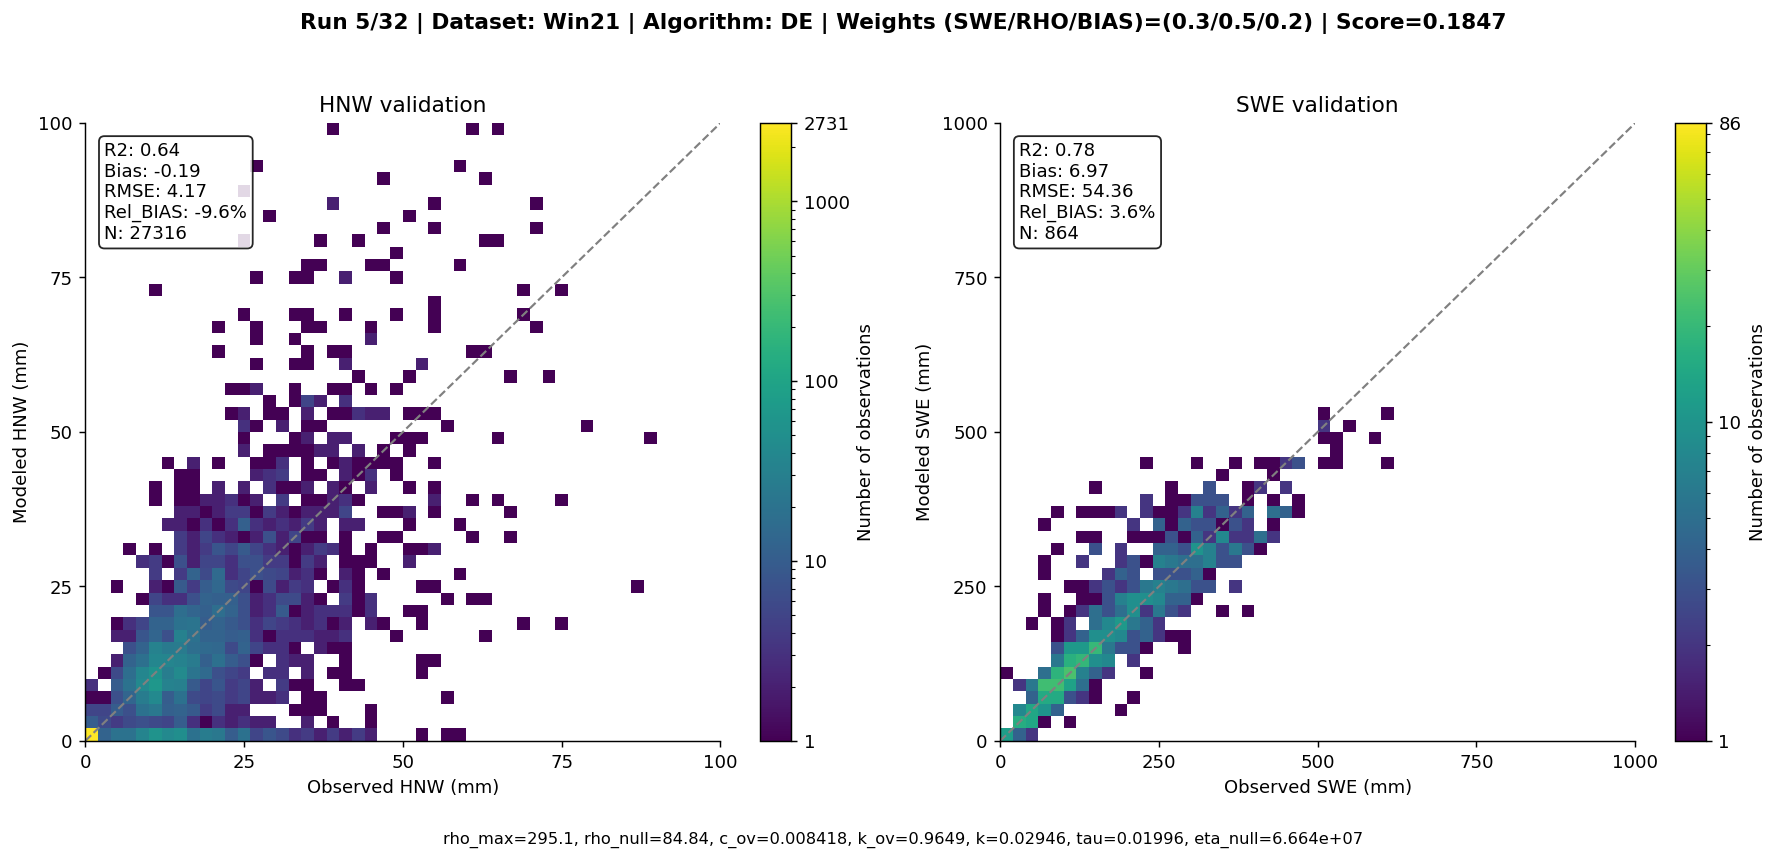

Calibration runs:  16%|█▌        | 5/32 [02:28<14:06, 31.34s/it]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


In [ ]:
from pathlib import Path
import os
import sys
import io
import warnings
from contextlib import redirect_stdout
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from joblib import Parallel, delayed
from tqdm.auto import tqdm


def _find_repo_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/Users/jakobwerkgarner/code/mt_dsnow'),
    ]
    for c in candidates:
        if (c / 'snow_to_swe_master' / 'main.py').exists():
            return c.resolve()
    raise FileNotFoundError('Could not locate repository root containing snow_to_swe_master/main.py')


repo_root = _find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / 'snow_to_swe_master') not in sys.path:
    sys.path.insert(0, str(repo_root / 'snow_to_swe_master'))

import HNW_validation.HNW_validation_helper as val_helper
from main import SnowToSwe

SHOW_SNOWTOSWE_BANNER = False


def _plot_validation_on_ax(ax, x, y, stats, title, lim, xlabel, ylabel):
    vmax = max(1, len(x) / 10)

    h = ax.hist2d(
        x, y,
        bins=50,
        range=[lim, lim],
        norm=LogNorm(vmin=1, vmax=vmax),
        cmap='viridis',
    )

    cb = plt.colorbar(h[3], ax=ax, label='Number of observations')
    ticks = [t for t in [1, 10, 100, 1000, 10000] if t <= vmax]
    if vmax not in ticks:
        ticks.append(vmax)
    cb.set_ticks(ticks)
    cb.set_ticklabels([f'{int(t)}' for t in ticks[:-1]] + [f'{int(vmax)}'])

    ax.plot(lim, lim, '--', color='gray', linewidth=1.2)
    ticks_xy = np.linspace(lim[0], lim[1], 5)
    ax.set_xticks(ticks_xy)
    ax.set_yticks(ticks_xy)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12)

    textstr = (
        f"R2: {stats['R2']:.2f}\n"
        f"Bias: {stats['Bias']:.2f}\n"
        f"RMSE: {stats['RMSE']:.2f}\n"
        f"Rel_BIAS: {stats['Rel_BIAS']:.1%}\n"
        f"N: {stats['N']}"
    )
    ax.text(
        0.03, 0.97, textstr,
        transform=ax.transAxes,
        fontsize=10,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.grid(False)


def _process_station_winter(station_name, winter_year, time_idx, hs_values, snow_to_swe):
    try:
        hs = pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None

        # SnowToSwe expects snow-free boundaries
        if hs.iloc[0] != 0:
            hs.iloc[0] = 0.0
        if hs.iloc[-1] != 0:
            hs.iloc[-1] = 0.0

        swe_list = snow_to_swe.convert_list(hs.tolist(), timestep=24, verbose=False)
        if swe_list is None:
            return None

        swe_arr = np.asarray(swe_list, dtype=float)
        if swe_arr.shape[0] != len(hs):
            return None

        return (station_name, winter_year, time_idx, swe_arr)
    except Exception as e:
        return ('__ERROR__', station_name, f'winter {winter_year}/{winter_year + 1}: {e}')


def _run_and_plot_one_calibration(row, base_data, tasks, out_dir, run_idx, total_runs, SnowToSwe):
    if SHOW_SNOWTOSWE_BANNER:
        snow_to_swe = SnowToSwe(
            rho_max=float(row['rho.max_phys']),
            rho_null=float(row['rho.null_phys']),
            c_ov=float(row['c.ov_phys']),
            k_ov=float(row['k.ov_phys']),
            k=float(row['k_phys']),
            tau=float(row['tau_phys']),
            eta_null=float(row['eta.null_phys']),
        )
    else:
        with redirect_stdout(io.StringIO()):
            snow_to_swe = SnowToSwe(
                rho_max=float(row['rho.max_phys']),
                rho_null=float(row['rho.null_phys']),
                c_ov=float(row['c.ov_phys']),
                k_ov=float(row['k.ov_phys']),
                k=float(row['k_phys']),
                tau=float(row['tau_phys']),
                eta_null=float(row['eta.null_phys']),
            )

    mag = base_data.copy()
    mag['SWE_mod'] = xr.full_like(mag['HS'], np.nan)

    results = Parallel(n_jobs=-1, return_as='generator')(
        delayed(_process_station_winter)(stn, y, tidx, hsv, snow_to_swe)
        for (stn, y, tidx, hsv) in tasks
    )

    errors = 0
    ok_tasks = 0
    for result in results:
        if result is None:
            continue
        if isinstance(result, tuple) and result and result[0] == '__ERROR__':
            errors += 1
            continue

        station_name, _, time_idx, swe_arr = result
        mag['SWE_mod'].loc[dict(station=station_name, time=time_idx)] = swe_arr
        ok_tasks += 1

    hnw_mod = mag['SWE_mod'].diff(dim='time').clip(min=0)
    hnw_mod = hnw_mod.reindex(time=mag['time'])
    mag['HNW_mod'] = hnw_mod

    all_df = (
        mag[['HNW', 'HNW_mod', 'SWE', 'SWE_mod', 'HS']]
        .to_dataframe()
        .reset_index()
        .rename(columns={'HNW': 'HNW_obs', 'SWE': 'SWE_obs'})
    )

    # Match the original validation filtering strategy
    swe_val = all_df[all_df['SWE_obs'].notna()].copy()
    swe_val.index = pd.to_datetime(swe_val['time'])
    swe_val = val_helper._filter_season(swe_val, full_season=True)
    swe_val = swe_val.dropna(subset=['SWE_obs', 'SWE_mod'])
    swe_val = swe_val[swe_val['SWE_obs'] >= 0]
    swe_val = swe_val[np.isfinite(swe_val['SWE_obs']) & np.isfinite(swe_val['SWE_mod'])]

    hnw_val = all_df[all_df['HNW_obs'].notna()].copy()
    hnw_val.index = pd.to_datetime(hnw_val['time'])
    hnw_val = val_helper._filter_season(hnw_val, full_season=False)
    hnw_val = hnw_val.dropna(subset=['HNW_obs', 'HNW_mod'])
    hnw_val = hnw_val[hnw_val['HNW_obs'] >= 0]
    hnw_val = hnw_val[np.isfinite(hnw_val['HNW_obs']) & np.isfinite(hnw_val['HNW_mod'])]

    hs = val_helper._calculate_metrics(hnw_val['HNW_obs'].values, hnw_val['HNW_mod'].values)
    hs['N'] = len(hnw_val)
    ss = val_helper._calculate_metrics(swe_val['SWE_obs'].values, swe_val['SWE_mod'].values)
    ss['N'] = len(swe_val)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    _plot_validation_on_ax(
        axes[0],
        hnw_val['HNW_obs'].values,
        hnw_val['HNW_mod'].values,
        hs,
        title='HNW validation',
        lim=[0, 100],
        xlabel='Observed HNW (mm)',
        ylabel='Modeled HNW (mm)',
    )
    _plot_validation_on_ax(
        axes[1],
        swe_val['SWE_obs'].values,
        swe_val['SWE_mod'].values,
        ss,
        title='SWE validation',
        lim=[0, 1000],
        xlabel='Observed SWE (mm)',
        ylabel='Modeled SWE (mm)',
    )

    meta_title = (
        f"Run {run_idx}/{total_runs} | Dataset: {row['dataset']} | Algorithm: {row['algorithm']} | "
        f"Weights (SWE/RHO/BIAS)=({row['w_SWE_NRMSE']:.1f}/{row['w_RHO_NRMSE']:.1f}/{row['w_SWE_NBIAS']:.1f}) | "
        f"Score={row['best_value']:.4f}"
    )
    fig.suptitle(meta_title, fontsize=12, fontweight='bold', y=1.03)

    param_text = (
        f"rho_max={row['rho.max_phys']:.4g}, rho_null={row['rho.null_phys']:.4g}, c_ov={row['c.ov_phys']:.4g}, "
        f"k_ov={row['k.ov_phys']:.4g}, k={row['k_phys']:.4g}, tau={row['tau_phys']:.4g}, eta_null={row['eta.null_phys']:.4g}"
    )
    fig.text(0.5, -0.02, param_text, ha='center', va='top', fontsize=9)
    plt.tight_layout()

    file_stub = (
        f"run_{run_idx:02d}__{row['dataset']}__{row['algorithm']}__"
        f"SWE_{row['w_SWE_NRMSE']:.1f}_RHO_{row['w_RHO_NRMSE']:.1f}_BIAS_{row['w_SWE_NBIAS']:.1f}"
    ).replace(' ', '_').replace('/', '-')
    out_file = out_dir / f"{file_stub}.png"
    fig.savefig(out_file, dpi=250, bbox_inches='tight')
    plt.show()

    return {
        'run_idx': run_idx,
        'dataset': row['dataset'],
        'algorithm': row['algorithm'],
        'w_SWE': row['w_SWE_NRMSE'],
        'w_RHO': row['w_RHO_NRMSE'],
        'w_BIAS': row['w_SWE_NBIAS'],
        'score': row['best_value'],
        'HNW_RMSE': hs['RMSE'],
        'HNW_R2': hs['R2'],
        'SWE_RMSE': ss['RMSE'],
        'SWE_R2': ss['R2'],
        'ok_tasks': ok_tasks,
        'errors': errors,
        'figure': str(out_file),
    }


warnings.filterwarnings('ignore', category=FutureWarning, module=r'main')

mag25_candidates = [
    repo_root / 'calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc',
    Path('/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc'),
]
mag25_path = next((p for p in mag25_candidates if p.exists()), None)
if mag25_path is None:
    raise FileNotFoundError('Could not find Mag25_all.nc')

base_data = xr.open_dataset(mag25_path).drop_sel(station='Weisfluh_Joch')
times = pd.to_datetime(base_data['time'].values)
hyd_year = np.where(times.month > 8, times.year, times.year - 1)
winter_years = np.unique(hyd_year)
station_list = base_data['station'].values
hs_by_station = {s: base_data['HS'].sel(station=s).values for s in station_list}

tasks = []
for stn in station_list:
    hs_full = hs_by_station[stn]
    for y in winter_years:
        mask = hyd_year == y
        time_idx = times[mask].values
        hs_vals = hs_full[mask]
        tasks.append((stn, int(y), time_idx, hs_vals))

print(f'Prepared {len(tasks)} station×winter tasks for validation.')

out_dir = repo_root / 'calibration/plots/hnw_swe_validation_per_run'
out_dir.mkdir(parents=True, exist_ok=True)

runs = df_filtered.copy().reset_index(drop=True)
print(f'Generating side-by-side HNW/SWE plots for {len(runs)} calibration runs...')

summaries = []
for i, (_, row) in enumerate(tqdm(runs.iterrows(), total=len(runs), desc='Calibration runs'), start=1):
    try:
        summary = _run_and_plot_one_calibration(
            row=row,
            base_data=base_data,
            tasks=tasks,
            out_dir=out_dir,
            run_idx=i,
            total_runs=len(runs),
            SnowToSwe=SnowToSwe,
        )
        summaries.append(summary)
    except Exception as e:
        print(f'[WARNING] Run {i} failed ({row["dataset"]} / {row["algorithm"]}): {e}')

validation_summary = pd.DataFrame(summaries)
display(validation_summary)
print(f'Finished. Saved figures to: {out_dir}')